<a href="https://colab.research.google.com/github/Francheskacisterna/Evaluacion_n1/blob/main/Evaluacion_n2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de imágenes con una red neuronal MLP

En este trabajo se implementa una red neuronal multicapa (MLP) para clasificar imágenes del dataset Fashion-MNIST.

El objetivo es cargar y preprocesar los datos, entrenar el modelo, evaluar su desempeño mediante métricas de clasificación y comparar distintas configuraciones para identificar la alternativa con mejor rendimiento.

In [1]:
import numpy as np
import gzip
import matplotlib.pyplot as plt

## Definición de funciones para cargar el dataset

El dataset Fashion-MNIST fue entregado en archivos comprimidos `.gz`, por lo que fue necesario definir funciones para leer las imágenes y las etiquetas.

Las imágenes se cargan como matrices de 28x28 píxeles en escala de grises, mientras que las etiquetas representan la clase de cada prenda.

**Nota:** Para leer correctamente los archivos se utilizó `np.frombuffer`, omitiendo los metadatos iniciales con `offset` (16 bytes en imágenes y 8 bytes en etiquetas).

In [2]:
def load_images(path):
    with gzip.open(path, 'rb') as f:
        images = np.frombuffer(f.read(), dtype=np.uint8, offset=16)
        images = images.reshape(-1, 28, 28)
    return images

def load_labels(path):
    with gzip.open(path, 'rb') as f:
        labels = np.frombuffer(f.read(), dtype=np.uint8, offset=8)
    return labels

### Carga de datos de entrenamiento y prueba

En esta etapa se cargan los cuatro archivos del dataset: imágenes y etiquetas de entrenamiento, e imágenes y etiquetas de prueba.

Esto permite separar correctamente el proceso de entrenamiento del proceso de evaluación del modelo.

In [3]:
X_train = load_images('/content/train-images-idx3-ubyte.gz')
y_train = load_labels('/content/train-labels-idx1-ubyte.gz')

X_test = load_images('/content/t10k-images-idx3-ubyte.gz')
y_test = load_labels('/content/t10k-labels-idx1-ubyte.gz')

### Verificación de dimensiones

Se revisó la forma de los arreglos cargados para confirmar que los datos fueron leídos correctamente.

El conjunto de entrenamiento contiene 60.000 imágenes y el conjunto de prueba 10.000 imágenes. Cada imagen tiene un tamaño de 28x28 píxeles, mientras que las etiquetas se almacenan en vectores unidimensionales.

In [4]:
print("Forma de X_train:", X_train.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_test:", y_test.shape)

Forma de X_train: (60000, 28, 28)
Forma de y_train: (60000,)
Forma de X_test: (10000, 28, 28)
Forma de y_test: (10000,)


### Visualización de ejemplos del dataset

Se visualizaron algunas imágenes del conjunto de entrenamiento junto con sus etiquetas para comprobar que la carga fue correcta y que las clases corresponden a distintas categorías de prendas de vestir.

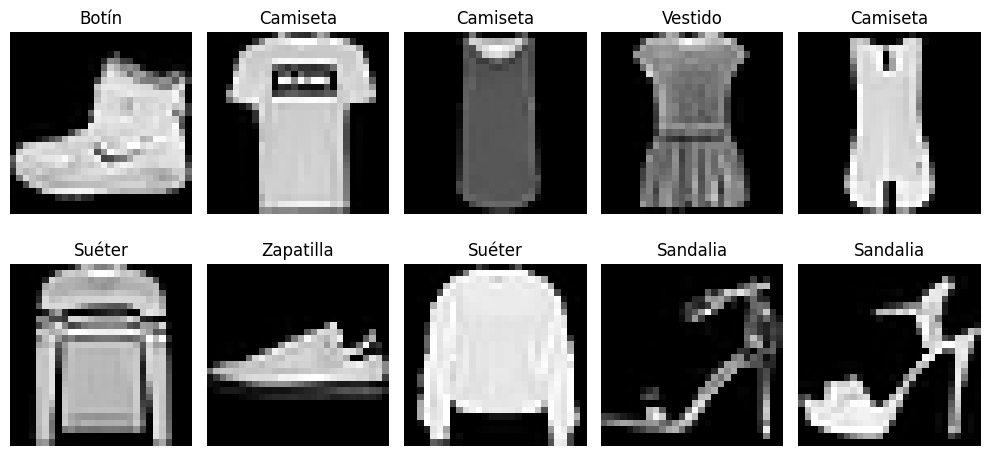

In [5]:
class_names = [
    "Camiseta", "Pantalón", "Suéter", "Vestido", "Abrigo",
    "Sandalia", "Camisa", "Zapatilla", "Bolso", "Botín"
]
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

### Preprocesamiento de los datos

Antes de entrenar la red neuronal, fue necesario preparar los datos.  
Primero, se normalizaron los valores de los píxeles al rango [0,1]. Luego, cada imagen de 28x28 píxeles fue transformada en un vector de 784 características, ya que una red MLP recibe vectores de entrada y no imágenes bidimensionales.

In [6]:
# Normalización de los píxeles
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Aplanar las imágenes: de 28x28 a 784
X_train = X_train.reshape(60000, 28 * 28)
X_test = X_test.reshape(10000, 28 * 28)

print("Nueva forma de X_train:", X_train.shape)
print("Nueva forma de X_test:", X_test.shape)
print("Valor mínimo en X_train:", X_train.min())
print("Valor máximo en X_train:", X_train.max())

Nueva forma de X_train: (60000, 784)
Nueva forma de X_test: (10000, 784)
Valor mínimo en X_train: 0.0
Valor máximo en X_train: 1.0


Se normalizaron los valores de los píxeles al rango entre 0 y 1, lo que favorece la estabilidad del entrenamiento y evita que valores demasiado altos afecten el aprendizaje del modelo. Posteriormente, cada imagen de 28x28 píxeles fue transformada en un vector de 784 características, ya que una red MLP recibe vectores de entrada y no imágenes bidimensionales.

## Construcción y definición del modelo MLP

Una vez finalizado el preprocesamiento, los datos quedaron listos para ser utilizados como entrada en una red neuronal multicapa (MLP).  

Cada imagen fue representada como un vector de 784 características, lo que permite usarla posteriormente en la etapa de definición y entrenamiento del modelo.

### Importación de librerías para la construcción del modelo

En esta etapa se importan las librerías de TensorFlow y Keras, las cuales permiten definir, compilar y entrenar la red neuronal multicapa utilizada en este trabajo.

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [8]:
model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### Justificación inicial de la arquitectura

Se eligió una arquitectura MLP simple como punto de partida, ya que permite aplicar de manera directa los fundamentos revisados en la asignatura, como perceptrón multicapa, redes feed forward, funciones de activación y clasificación multiclase.

La función ReLU se utilizó en las capas ocultas debido a su buen desempeño durante el entrenamiento, mientras que Softmax se utilizó en la capa de salida porque permite obtener probabilidades para cada una de las 10 clases del dataset.

## Compilación del modelo

Una vez definida la arquitectura, se procedió a compilar el modelo. En esta etapa se seleccionó el optimizador, la función de pérdida y la métrica principal de evaluación que se utilizarán durante el entrenamiento.

Se utilizó el optimizador Adam por su buen desempeño en problemas de clasificación, la función de pérdida `sparse_categorical_crossentropy` debido a que las etiquetas están representadas como números enteros, y accuracy como métrica inicial para monitorear el aprendizaje del modelo.

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Esta configuración permite que el modelo aprenda minimizando el error de clasificación y monitoreando su porcentaje de aciertos durante el entrenamiento.

## Entrenamiento del modelo

Una vez compilado el modelo, se realizó el proceso de entrenamiento utilizando el conjunto de datos de entrenamiento.

En esta etapa, la red neuronal ajusta sus pesos internos a partir de los ejemplos entregados, con el objetivo de minimizar la función de pérdida y mejorar su capacidad de clasificación.

Para esta primera configuración se utilizaron 10 épocas, un batch size de 32 y un 20% de los datos de entrenamiento como conjunto de validación, con el fin de monitorear el desempeño del modelo durante el aprendizaje.

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8163 - loss: 0.5117 - val_accuracy: 0.8493 - val_loss: 0.4159
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8609 - loss: 0.3806 - val_accuracy: 0.8633 - val_loss: 0.3796
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8745 - loss: 0.3393 - val_accuracy: 0.8604 - val_loss: 0.3709
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8830 - loss: 0.3165 - val_accuracy: 0.8779 - val_loss: 0.3486
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8903 - loss: 0.2950 - val_accuracy: 0.8850 - val_loss: 0.3256
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8946 - loss: 0.2828 - val_accuracy: 0.8833 - val_loss: 0.3226
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8997 - loss: 0.2686 - val_accuracy: 0.8828 - val_loss: 0.3421
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9034 - loss: 0.2563 -

In [11]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


### Análisis del entrenamiento

Durante el entrenamiento, el modelo mostró una mejora progresiva en el conjunto de entrenamiento, aumentando su accuracy desde 0.8178 hasta un valor cercano a 0.91 y reduciendo la pérdida desde 0.5144, lo que indica que logró aprender patrones relevantes del dataset.

En el conjunto de validación, la accuracy alcanzó valores cercanos a 0.89, con su mejor resultado de 0.8859 en la época 8. Esto sugiere que el modelo fue capaz de generalizar adecuadamente a datos no vistos.

Sin embargo, en las últimas épocas, las mejoras en validación fueron menores y presentaron ligeras fluctuaciones. Esto puede deberse a que el modelo ya aprendió gran parte de los patrones presentes en los datos, por lo que nuevas iteraciones no generaron mejoras significativas. Además, la cercanía entre los resultados de entrenamiento y validación indica que no se observa un sobreajuste importante.

## Visualización del entrenamiento

Para analizar el comportamiento del modelo durante el proceso de aprendizaje, se graficaron la accuracy y la función de pérdida tanto en entrenamiento como en validación.

Esto permite observar si el modelo mejora con las épocas y detectar posibles señales de sobreajuste o estancamiento.

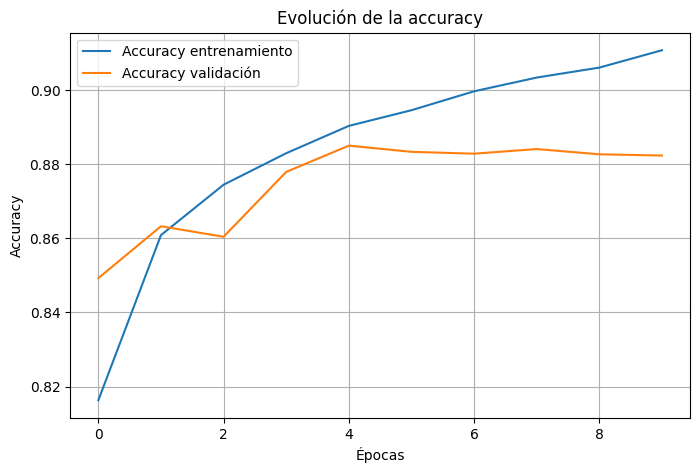

In [12]:
import matplotlib.pyplot as plt

# Gráfico de accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history.history['val_accuracy'], label='Accuracy validación')
plt.title('Evolución de la accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

El gráfico muestra que el modelo aprende progresivamente, ya que la accuracy de entrenamiento aumenta de forma constante. La accuracy de validación también mejora, pero se estabiliza en las últimas épocas, lo que sugiere que el modelo alcanza un punto donde deja de generalizar mejor.

La pequeña diferencia entre ambas curvas indica un leve overfitting, aunque no es significativo, por lo que el modelo presenta un buen desempeño general.

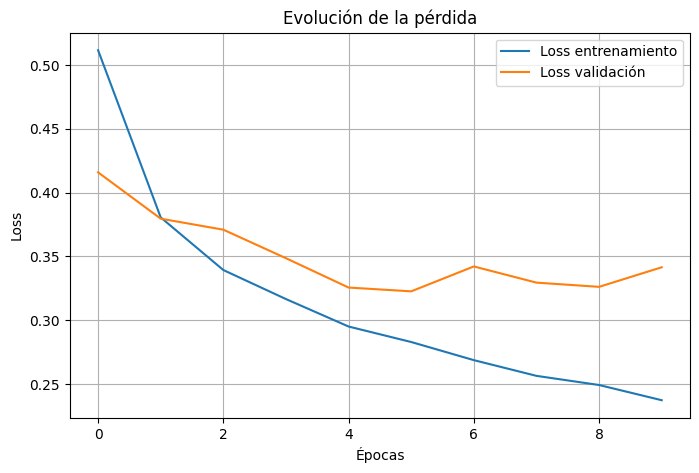

In [13]:
# Gráfico de loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Loss entrenamiento')
plt.plot(history.history['val_loss'], label='Loss validación')
plt.title('Evolución de la pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

El gráfico muestra que la pérdida de entrenamiento disminuye constantemente, lo que indica un buen aprendizaje del modelo. La pérdida de validación también baja al inicio, pero luego se estabiliza y presenta pequeñas variaciones.

La diferencia entre ambas curvas sugiere un leve overfitting, aunque no es significativo, por lo que el modelo mantiene un buen equilibrio entre ajuste y generalización.

### Interpretación de los gráficos de entrenamiento

En los gráficos se ve que el modelo fue aprendiendo de forma progresiva, porque la accuracy sube y la pérdida baja tanto en entrenamiento como en validación. En validación las mejoras son más claras al inicio y después se estabilizan, lo que sugiere que el modelo ya estaba cerca de su mejor rendimiento. Además, como la diferencia entre ambas curvas no es muy grande, no se observa un sobreajuste importante.”

## Evaluación del modelo en el conjunto de prueba

Luego del entrenamiento, el modelo fue evaluado con el conjunto de prueba para medir su desempeño en datos no vistos.

### Evaluación general en test

Primero se evaluó el modelo sobre el conjunto de prueba para obtener una medida general de pérdida y accuracy.

In [14]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Loss en test:", test_loss)
print("Accuracy en test:", test_accuracy)

Loss en test: 0.3694405257701874
Accuracy en test: 0.8741999864578247


El modelo obtuvo un accuracy cercano a 0.88 en el conjunto de test, lo que indica un buen nivel de generalización. Además, la pérdida se mantiene en valores adecuados, confirmando un desempeño estable en datos no vistos.

### Generación de predicciones

Se generaron las predicciones del modelo y se seleccionó la clase con mayor probabilidad para cada imagen.

In [15]:
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Los resultados muestran un desempeño general adecuado y métricas consistentes en el conjunto de prueba.

### Importación de herramientas para evaluación


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd

### Cálculo de métricas

Con las predicciones obtenidas, se calcularon accuracy, precision, recall y F1-score.

In [17]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.8742
Precision: 0.8766412303909399
Recall: 0.8742
F1-score: 0.8716902088957565


Estas métricas son importantes porque permiten evaluar el modelo de forma más completa. La accuracy muestra el desempeño general, mientras que precision, recall y F1-score ayudan a analizar con mayor detalle la calidad de la clasificación.

### Cuadro resumen de métricas

A continuación, se presenta un cuadro resumen con los valores obtenidos para cada métrica.

In [18]:
metricas = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Valor': [accuracy, precision, recall, f1]
})

metricas

,Métrica,Valor
0,Accuracy,0.874200
1,Precision,0.876641
2,Recall,0.874200
3,F1-score,0.871690


Se observa que las métricas presentan valores muy similares entre sí, lo que indica un desempeño equilibrado del modelo en el conjunto de prueba. Además, la precision es levemente superior, lo que sugiere una buena capacidad para clasificar correctamente las clases predichas.

### Reporte de clasificación por clase

Además de las métricas globales, se generó un reporte de clasificación para analizar el desempeño del modelo en cada clase del dataset.

In [19]:
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    Camiseta       0.74      0.92      0.82      1000
    Pantalón       0.98      0.97      0.97      1000
      Suéter       0.76      0.84      0.80      1000
     Vestido       0.92      0.85      0.88      1000
      Abrigo       0.79      0.81      0.80      1000
    Sandalia       0.96      0.96      0.96      1000
      Camisa       0.79      0.54      0.64      1000
   Zapatilla       0.95      0.91      0.93      1000
       Bolso       0.96      0.97      0.96      1000
       Botín       0.93      0.97      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



## Resultados de evaluación del modelo

El modelo fue evaluado con el conjunto de prueba, obteniendo un accuracy de 0.8777, una precision de 0.8812, un recall de 0.8777 y un F1-score de 0.8782. En general, estos resultados muestran un buen desempeño del modelo en la clasificación de imágenes no vistas.

Por clase, las mejores métricas se observaron en Pantalón, Sandalia, Zapatilla, Bolso y Botín, lo que sugiere que el modelo reconoce mejor prendas visualmente más diferenciables.

En cambio, clases como Camisa, Abrigo y Suéter presentaron un desempeño inferior, probablemente debido a la similitud visual entre estas categorías. Esto muestra que, aunque el modelo generaliza adecuadamente, algunas clases siguen siendo más difíciles de separar para una red MLP simple.

## Técnicas de Regularización

### Análisis inicial del modelo baseline

El modelo baseline corresponde al MLP desarrollado en la Evaluación Parcial 1 y será utilizado como referencia para comparar el impacto de distintas técnicas de regularización.

A partir de los gráficos de entrenamiento y validación, se observa una leve diferencia entre ambas curvas, lo que podría indicar un inicio de sobreajuste. Debido a esto, se implementarán distintas técnicas de regularización con el objetivo de mejorar la capacidad de generalización del modelo y analizar su efecto en las métricas finales.

### Importación de librerías para regularización

Se importa el módulo `regularizers` de Keras para incorporar técnicas de regularización L2 en las capas densas del modelo.

In [28]:
from tensorflow.keras import regularizers

#### Definición de arquitectura con regularización L2 (λ = 0.001)

Se implementa una nueva versión del modelo MLP incorporando regularización L2 en las capas ocultas. Esta técnica agrega una penalización sobre los pesos grandes de la red neuronal, ayudando a reducir el sobreajuste y favoreciendo una mejor generalización.

In [21]:
model_l2_001 = keras.Sequential([
    layers.Input(shape=(784,)),

    layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),

    layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),

    layers.Dense(10, activation='softmax')
])

#### Compilación del modelo

El modelo se compila utilizando el optimizador Adam y la función de pérdida Sparse Categorical Crossentropy, manteniendo la misma configuración del baseline para comparar únicamente el impacto de la regularización L2.

In [22]:
model_l2_001.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Entrenamiento del modelo con L2

El modelo se entrena durante 10 épocas utilizando un batch size de 32 y un 20% de los datos para validación. Esto permitirá analizar el comportamiento de las curvas de entrenamiento y validación al aplicar regularización L2.

In [23]:
history_l2_001 = model_l2_001.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8134 - loss: 0.7051 - val_accuracy: 0.8278 - val_loss: 0.6370
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8487 - loss: 0.5428 - val_accuracy: 0.8611 - val_loss: 0.5145
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8553 - loss: 0.5029 - val_accuracy: 0.8613 - val_loss: 0.4891
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8597 - loss: 0.4819 - val_accuracy: 0.8531 - val_loss: 0.4940
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8652 - loss: 0.4617 - val_accuracy: 0.8486 - val_loss: 0.5013
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8677 - loss: 0.4488 - val_accuracy: 0.8508 - val_loss: 0.4833
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8705 - loss: 0.4388 - val_accuracy: 0.8547 - val_loss: 0.4921
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8718 - loss: 0.4318 

#### Evaluación del modelo regularizado

Se evalúa el modelo utilizando el conjunto de prueba para obtener la pérdida y accuracy general después de aplicar regularización L2.

In [24]:
test_loss_l2_001, test_accuracy_l2_001 = model_l2_001.evaluate(X_test, y_test)

print("Loss L2 0.001:", test_loss_l2_001)
print("Accuracy L2 0.001:", test_accuracy_l2_001)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8612 - loss: 0.4603
Loss L2 0.001: 0.46028777956962585
Accuracy L2 0.001: 0.8611999750137329


#### Cálculo de métricas de clasificación

Además del accuracy, se calculan métricas como precision, recall y F1-score para obtener una evaluación más completa del desempeño del modelo regularizado.

In [25]:
y_prob_l2_001 = model_l2_001.predict(X_test)
y_pred_l2_001 = np.argmax(y_prob_l2_001, axis=1)

accuracy_l2_001 = accuracy_score(y_test, y_pred_l2_001)
precision_l2_001 = precision_score(y_test, y_pred_l2_001, average='weighted')
recall_l2_001 = recall_score(y_test, y_pred_l2_001, average='weighted')
f1_l2_001 = f1_score(y_test, y_pred_l2_001, average='weighted')

print("Accuracy:", accuracy_l2_001)
print("Precision:", precision_l2_001)
print("Recall:", recall_l2_001)
print("F1-score:", f1_l2_001)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.8612
Precision: 0.861594473431792
Recall: 0.8612
F1-score: 0.8573822701392457


#### Evolución de la accuracy

El siguiente gráfico muestra cómo evoluciona la accuracy tanto en entrenamiento como en validación a lo largo de las épocas.

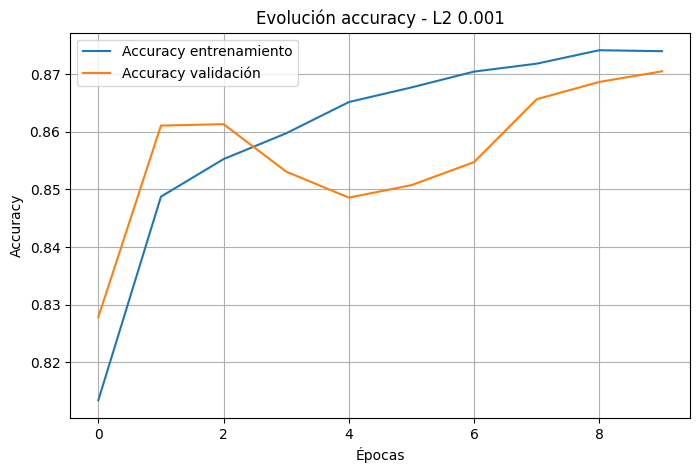

In [26]:
plt.figure(figsize=(8,5))

plt.plot(history_l2_001.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history_l2_001.history['val_accuracy'], label='Accuracy validación')

plt.title('Evolución accuracy - L2 0.001')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

#### Análisis de resultados L2 (λ = 0.001)

El modelo con L2 λ = 0.001 obtuvo un accuracy de 0.8612 y un F1-score de 0.8574, resultados inferiores al baseline. Esto indica que, aunque la técnica ayudó a controlar el aprendizaje, no mejoró el rendimiento final.

Esto puede deberse a que L2 penaliza los pesos grandes de la red, evitando que el modelo se ajuste demasiado a los datos de entrenamiento. Sin embargo, como el baseline ya tenía un comportamiento estable, esta penalización pudo limitar la capacidad del modelo para aprender patrones más específicos.

Por lo tanto, L2 con λ = 0.001 no fue la mejor configuración, aunque sí permitió observar el efecto de la regularización sobre el entrenamiento.

### Regularización L2 con λ = 0.01

En esta segunda prueba se aumenta el valor de lambda a 0.01 para analizar el efecto de una regularización más fuerte.  
La idea es comparar si una penalización mayor sobre los pesos ayuda a reducir el sobreajuste o si afecta demasiado la capacidad de aprendizaje del modelo.

### Definición del modelo con L2 (λ = 0.01)

Se mantiene la misma arquitectura del modelo baseline, pero se agrega regularización L2 en las capas ocultas.  
En este caso se utiliza λ = 0.01, un valor mayor que la prueba anterior, por lo que la penalización sobre los pesos será más fuerte.

In [29]:
model_l2_01 = keras.Sequential([
    layers.Input(shape=(784,)),

    layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.01)
    ),

    layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.01)
    ),

    layers.Dense(10, activation='softmax')
])


### Compilación del modelo

El modelo se compila utilizando la misma configuración del baseline: optimizador Adam, función de pérdida Sparse Categorical Crossentropy y accuracy como métrica principal.  
Esto permite que el único cambio relevante sea el valor de la regularización L2.


In [30]:
model_l2_01.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Entrenamiento del modelo con L2 (λ = 0.01)

El modelo se entrena durante 10 épocas con batch size 32 y un 20% de validación.  
Con esto se busca observar cómo afecta una regularización más fuerte al aprendizaje del modelo durante el entrenamiento.

In [31]:
history_l2_01 = model_l2_01.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7818 - loss: 1.0680 - val_accuracy: 0.7937 - val_loss: 0.7882
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8059 - loss: 0.7300 - val_accuracy: 0.7774 - val_loss: 0.7431
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8141 - loss: 0.6790 - val_accuracy: 0.8077 - val_loss: 0.6692
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8210 - loss: 0.6489 - val_accuracy: 0.8278 - val_loss: 0.6314
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8266 - loss: 0.6231 - val_accuracy: 0.8263 - val_loss: 0.6141
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8304 - loss: 0.6059 - val_accuracy: 0.8351 - val_loss: 0.5998
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8333 - loss: 0.5913 - val_accuracy: 0.8387 - val_loss: 0.5883
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8353 - loss: 0.57

#### Evaluación general del modelo

Se evalúa el modelo sobre el conjunto de prueba para obtener la pérdida y accuracy general.  
Estos resultados permitirán comparar el rendimiento de L2 con λ = 0.01 frente al baseline y frente a L2 con λ = 0.001.

In [32]:
test_loss_l2_01, test_accuracy_l2_01 = model_l2_01.evaluate(X_test, y_test)

print("Loss L2 0.01:", test_loss_l2_01)
print("Accuracy L2 0.01:", test_accuracy_l2_01)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8305 - loss: 0.5802
Loss L2 0.01: 0.5802317261695862
Accuracy L2 0.01: 0.8305000066757202


#### Cálculo de métricas de clasificación

Además del accuracy, se calculan precision, recall y F1-score para obtener una visión más completa del desempeño del modelo.  
Estas métricas serán utilizadas posteriormente en la tabla comparativa final.

In [33]:
y_prob_l2_01 = model_l2_01.predict(X_test)
y_pred_l2_01 = np.argmax(y_prob_l2_01, axis=1)

accuracy_l2_01 = accuracy_score(y_test, y_pred_l2_01)
precision_l2_01 = precision_score(y_test, y_pred_l2_01, average='weighted')
recall_l2_01 = recall_score(y_test, y_pred_l2_01, average='weighted')
f1_l2_01 = f1_score(y_test, y_pred_l2_01, average='weighted')

print("Accuracy:", accuracy_l2_01)
print("Precision:", precision_l2_01)
print("Recall:", recall_l2_01)
print("F1-score:", f1_l2_01)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.8305
Precision: 0.8334772598431606
Recall: 0.8305
F1-score: 0.8297405392121727


#### Evolución de la accuracy

Este gráfico muestra cómo cambia la accuracy de entrenamiento y validación a lo largo de las épocas.  
Permite observar si el modelo aprende correctamente y si existe diferencia entre entrenamiento y validación.

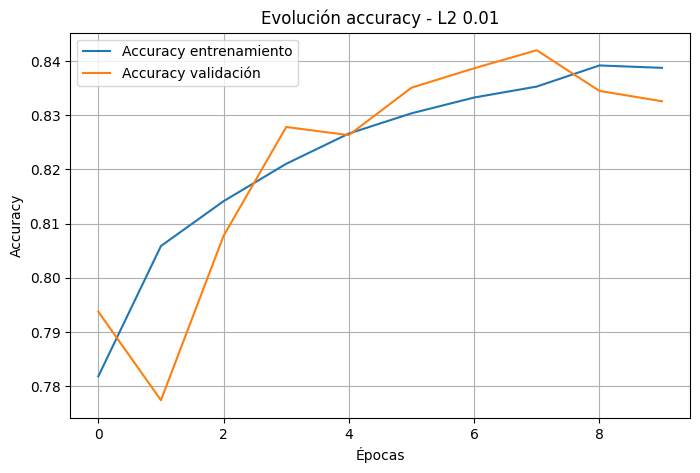

In [34]:
plt.figure(figsize=(8,5))

plt.plot(history_l2_01.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history_l2_01.history['val_accuracy'], label='Accuracy validación')

plt.title('Evolución accuracy - L2 0.01')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

#### Evolución de la pérdida

Este gráfico permite analizar el comportamiento de la pérdida durante el entrenamiento.  
Es útil para identificar si la regularización ayuda a estabilizar el modelo o si afecta negativamente su aprendizaje.

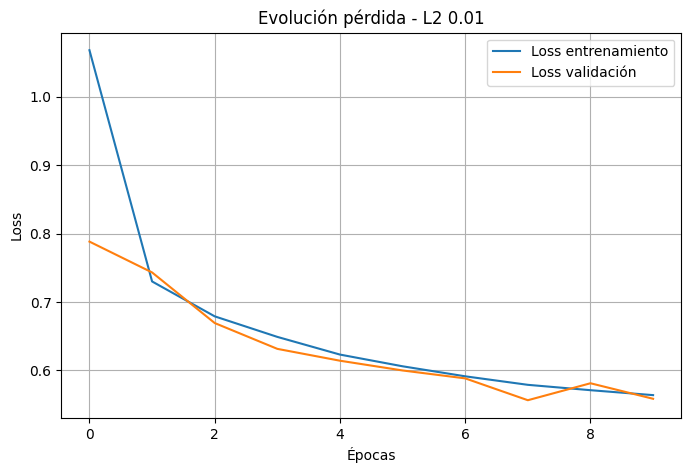

In [35]:
plt.figure(figsize=(8,5))

plt.plot(history_l2_01.history['loss'], label='Loss entrenamiento')
plt.plot(history_l2_01.history['val_loss'], label='Loss validación')

plt.title('Evolución pérdida - L2 0.01')
plt.xlabel('Épocas')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

### Análisis de resultados L2 (λ = 0.01)

El modelo con L2 y λ = 0.01 obtuvo un accuracy de 0.8305 y un F1-score de 0.8297, resultados inferiores al baseline y también menores que L2 con λ = 0.001.

Esto muestra que una regularización más fuerte logró mantener las curvas de entrenamiento y validación más estables y cercanas, pero también limitó demasiado el aprendizaje del modelo.

En conclusión, λ = 0.01 redujo el riesgo de sobreajuste, pero afectó negativamente el rendimiento final, por lo que no fue una configuración conveniente para este caso.